In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/offline_data_8192.csv" 

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [3]:
# ==========================================
# 2. LOAD DATA
# ==========================================
if not os.path.exists(CSV_PATH):
    print(f"❌ Error: File not found at {CSV_PATH}")
    print("Please check the path and try again.")
else:
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Successfully loaded data!")
    print(f"   Rows (Envs): {df.shape[0]}")
    print(f"   Columns:     {df.shape[1]}")
    print(f"Columns found: {list(df.columns)[:10]} ... and {len(df.columns)-10} more")

    # Display the dataframe
    display(df)

✅ Successfully loaded data!
   Rows (Envs): 40960
   Columns:     4849
Columns found: ['env_id', 'seed', 'range_type', 'start_t', 'end_t', 'gt_mass', 'gt_mu', 'gt_fric_force', 'cube_size', 'raw_ee_acc_t0_ax0'] ... and 4839 more


,env_id,seed,range_type,start_t,end_t,gt_mass,gt_mu,gt_fric_force,cube_size,raw_ee_acc_t0_ax0,...,pinn_ee_calc_force_t98_ax2,pinn_ee_calc_force_t98_ax3,pinn_ee_calc_force_t98_ax4,pinn_ee_calc_force_t98_ax5,pinn_ee_calc_force_t99_ax0,pinn_ee_calc_force_t99_ax1,pinn_ee_calc_force_t99_ax2,pinn_ee_calc_force_t99_ax3,pinn_ee_calc_force_t99_ax4,pinn_ee_calc_force_t99_ax5
0,0,42,m_all_mu_all,63,83,1.936309,0.210427,4.273018,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,42,m_all_mu_all,63,83,0.708472,0.512192,4.733294,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,42,m_all_mu_all,63,83,2.681930,0.235992,6.739134,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,42,m_all_mu_all,63,83,0.137902,0.292800,0.380912,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,42,m_all_mu_all,63,83,0.128281,0.284369,0.325899,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40955,8187,46,m_all_mu_all,63,83,1.915102,0.364559,8.235738,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40956,8188,46,m_all_mu_all,63,83,1.871232,0.387916,8.759247,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40957,8189,46,m_all_mu_all,63,83,1.915769,0.388007,8.971465,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40958,8190,46,m_all_mu_all,63,83,0.862823,0.222026,2.018958,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# --- FIX DATA TYPES ---
# The 'gt_fric_force' column was saved as strings (e.g., "[4.23]"). 
# We need to strip brackets and convert to float.
def clean_force_col(x):
    if isinstance(x, str):
        # Remove '[' and ']' and convert to float
        return float(x.strip('[]'))
    return x

if 'gt_fric_force' in df.columns:
    df['gt_fric_force'] = df['gt_fric_force'].apply(clean_force_col)
    print("✅ Fixed 'gt_fric_force' column types.")

✅ Fixed 'gt_fric_force' column types.


In [5]:
# Display the dataframe
display(df)

,env_id,seed,range_type,start_t,end_t,gt_mass,gt_mu,gt_fric_force,cube_size,raw_ee_acc_t0_ax0,...,pinn_ee_calc_force_t98_ax2,pinn_ee_calc_force_t98_ax3,pinn_ee_calc_force_t98_ax4,pinn_ee_calc_force_t98_ax5,pinn_ee_calc_force_t99_ax0,pinn_ee_calc_force_t99_ax1,pinn_ee_calc_force_t99_ax2,pinn_ee_calc_force_t99_ax3,pinn_ee_calc_force_t99_ax4,pinn_ee_calc_force_t99_ax5
0,0,42,m_all_mu_all,63,83,1.936309,0.210427,4.273018,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,42,m_all_mu_all,63,83,0.708472,0.512192,4.733294,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,42,m_all_mu_all,63,83,2.681930,0.235992,6.739134,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,42,m_all_mu_all,63,83,0.137902,0.292800,0.380912,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,42,m_all_mu_all,63,83,0.128281,0.284369,0.325899,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40955,8187,46,m_all_mu_all,63,83,1.915102,0.364559,8.235738,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40956,8188,46,m_all_mu_all,63,83,1.871232,0.387916,8.759247,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40957,8189,46,m_all_mu_all,63,83,1.915769,0.388007,8.971465,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40958,8190,46,m_all_mu_all,63,83,0.862823,0.222026,2.018958,0.15,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def get_sequence_data(row, prefix, seq_len=100, num_axes=6):
    """Reconstructs (100, 6) array from flattened columns like 'prefix_t0_ax0'"""
    data = np.zeros((seq_len, num_axes))
    for t in range(seq_len):
        for ax in range(num_axes):
            col = f"{prefix}_t{t}_ax{ax}"
            if col in row:
                data[t, ax] = row[col]
    return data

def get_flat_window(row, prefix, window_size=10):
    """Reconstructs 1D array from columns like 'prefix_0', 'prefix_1'"""
    data = np.zeros(window_size)
    for i in range(window_size):
        col = f"{prefix}_{i}"
        if col in row:
            data[i] = row[col]
    return data


--- Target Property Distributions ---


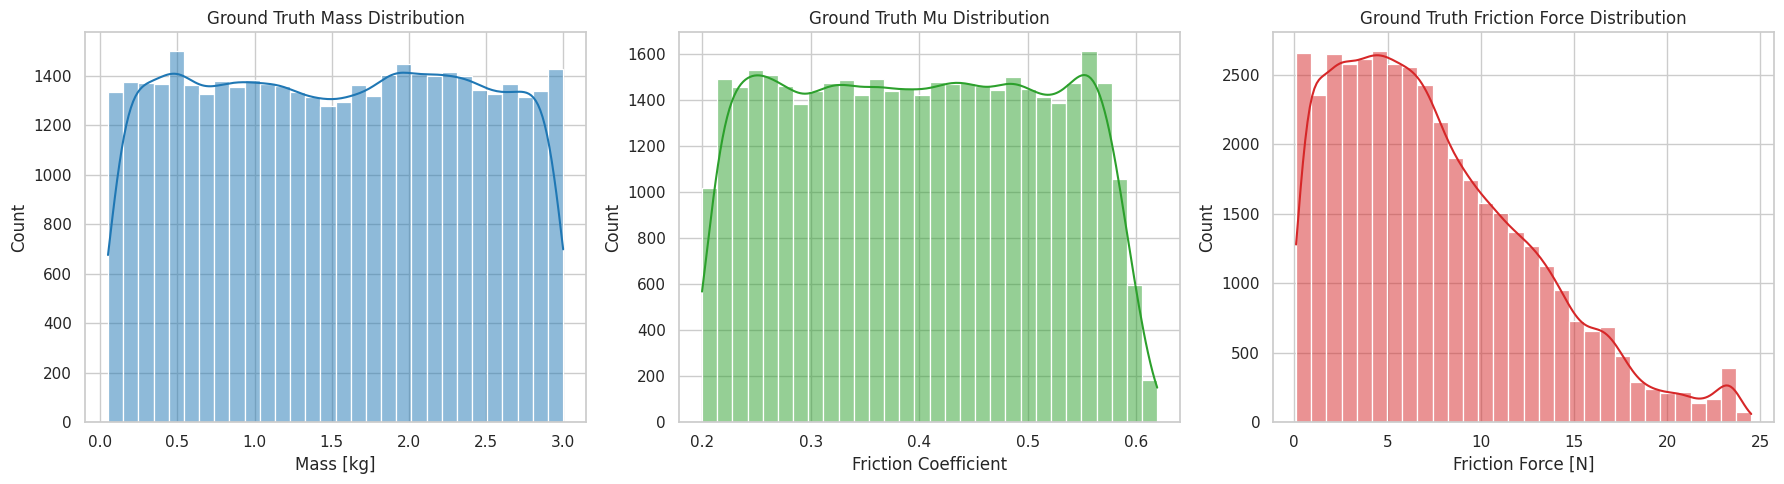

In [7]:
# ==========================================
# 4. DISTRIBUTION PLOTS (Targets)
# ==========================================
if 'df' in locals():
    print("\n--- Target Property Distributions ---")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Mass
    sns.histplot(df['gt_mass'], kde=True, ax=axes[0], color='tab:blue', bins=30)
    axes[0].set_title('Ground Truth Mass Distribution')
    axes[0].set_xlabel('Mass [kg]')
    
    # Friction Coeff
    sns.histplot(df['gt_mu'], kde=True, ax=axes[1], color='tab:green', bins=30)
    axes[1].set_title('Ground Truth Mu Distribution')
    axes[1].set_xlabel('Friction Coefficient')
    
    # Friction Force
    sns.histplot(df['gt_fric_force'], kde=True, ax=axes[2], color='tab:red', bins=30)
    axes[2].set_title('Ground Truth Friction Force Distribution')
    axes[2].set_xlabel('Friction Force [N]')
    
    plt.tight_layout()
    plt.show()


ANALYZING SAMPLE #3205
GT Mass: 0.650 kg
GT Mu:   0.258
GT Fric Force (Target): 1.816 N
Time Window: 63 -> 83


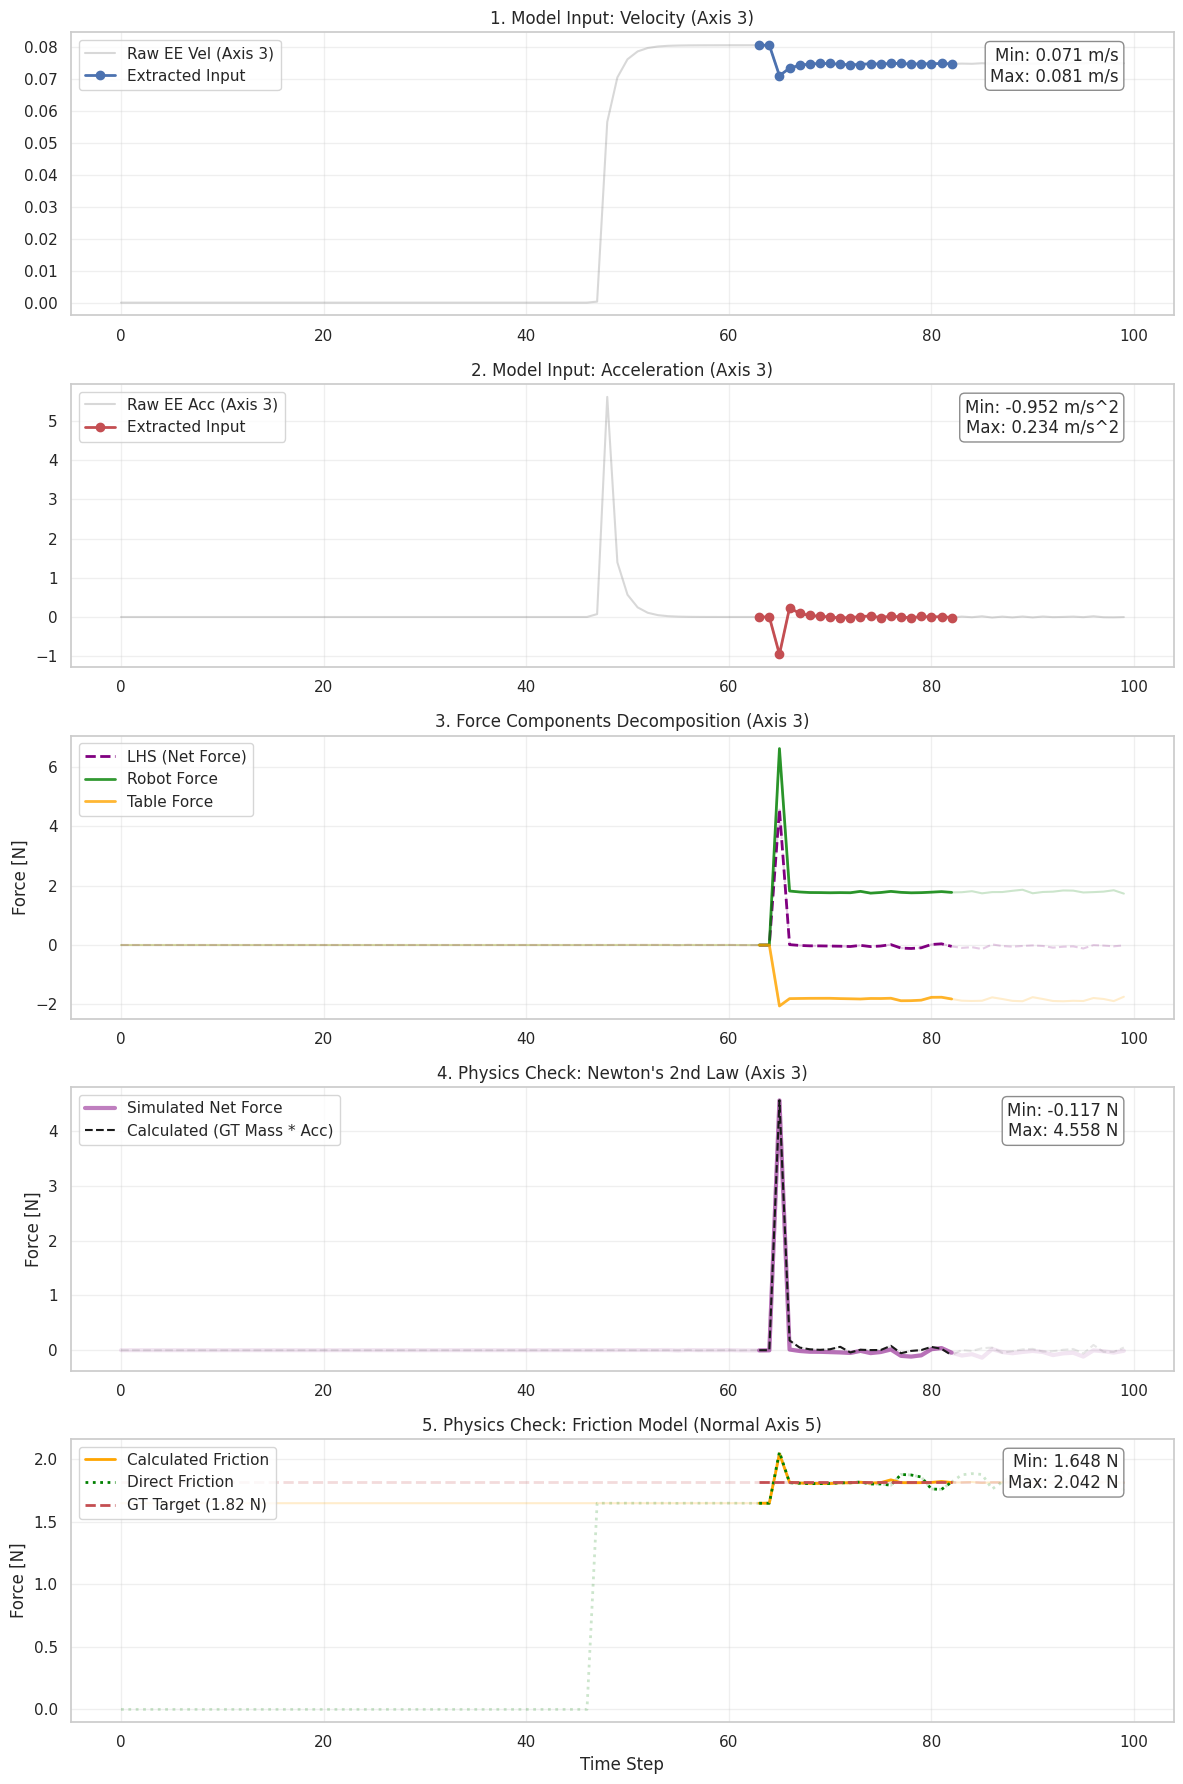

In [12]:
# ==========================================
# 5. INTEGRATED SAMPLE ANALYSIS (UPDATED WITH HIGHLIGHTS + MIN/MAX)
# ==========================================
if 'df' in locals():
    # --- CONFIGURATION ---
    AXIS_MOTION = 3   
    AXIS_VERTICAL = 5 
    G = 9.81

    # 1. Pick a single random sample for ALL plots
    sample_idx = np.random.randint(0, len(df))
    row = df.iloc[sample_idx]
    
    print(f"\n=======================================================")
    print(f"ANALYZING SAMPLE #{sample_idx}")
    print(f"=======================================================")
    print(f"GT Mass: {row['gt_mass']:.3f} kg")
    print(f"GT Mu:   {row['gt_mu']:.3f}")
    
    gt_fric_force_val = row['gt_fric_force']
    if isinstance(gt_fric_force_val, str):
        gt_fric_force_val = float(gt_fric_force_val.strip('[]'))
    print(f"GT Fric Force (Target): {gt_fric_force_val:.3f} N")
    print(f"Time Window: {int(row['start_t'])} -> {int(row['end_t'])}")

    # --- HELPER TO ADD MIN/MAX TEXT ---
    def add_min_max_text(ax, data, unit=""):
        dmin, dmax = np.min(data), np.max(data)
        stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # --- 2. EXTRACT DATA ---
    raw_acc = get_sequence_data(row, "raw_ee_acc")
    raw_vel = get_sequence_data(row, "raw_ee_vel")
    
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_acc = get_flat_window(row, "input_acc", win_len)
    input_vel = get_flat_window(row, "input_vel", win_len)
    
    lhs_wrench = get_sequence_data(row, "pinn_LHS_wrench")      
    rhs_acc = get_sequence_data(row, "pinn_RHS_acc")            
    robot_wrench = get_sequence_data(row, "pinn_robot_wrench")  
    table_wrench = get_sequence_data(row, "pinn_table_wrench")  
    
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)

    # --- 3. CALCULATIONS ---
    # Newton Check
    net_force_sim = lhs_wrench[:, AXIS_MOTION]
    acc_sim = rhs_acc[:, AXIS_MOTION]
    net_force_calc = row['gt_mass'] * acc_sim

    # Friction Check
    robot_force_vertical = robot_wrench[:, AXIS_VERTICAL]
    normal_force_calc = (row['gt_mass'] * G) - robot_force_vertical
    fric_force_calc_profile = row['gt_mu'] * normal_force_calc
    
    normal_force_direct = table_wrench[:, AXIS_VERTICAL]
    fric_force_direct_profile = row['gt_mu'] * normal_force_direct
    
    fric_force_gt_line = np.full_like(fric_force_calc_profile, gt_fric_force_val)

    # --- 4. PLOTTING ---
    fig, axes = plt.subplots(5, 1, figsize=(12, 18))
    
    # Plot 1: Velocity Input
    axes[0].plot(raw_vel[:, AXIS_MOTION], label=f'Raw EE Vel (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[0].plot(time_steps, input_vel, 'b-o', linewidth=2, label='Extracted Input')
    
    axes[0].set_title(f"1. Model Input: Velocity (Axis {AXIS_MOTION})")
    add_min_max_text(axes[0], input_vel, "m/s") # Add stats
    axes[0].legend(loc='upper left')

    # Plot 2: Acceleration Input
    axes[1].plot(raw_acc[:, AXIS_MOTION], label=f'Raw EE Acc (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[1].plot(time_steps, input_acc, 'r-o', linewidth=2, label='Extracted Input')
    
    axes[1].set_title(f"2. Model Input: Acceleration (Axis {AXIS_MOTION})")
    add_min_max_text(axes[1], input_acc, "m/s^2") # Add stats
    axes[1].legend(loc='upper left')

    # Plot 3: Component Breakdown
    lhs_val = lhs_wrench[:, AXIS_MOTION]
    robot_val = robot_wrench[:, AXIS_MOTION]
    table_val = table_wrench[:, AXIS_MOTION]
    
    # Background
    axes[2].plot(lhs_val, color='purple', linestyle='--', alpha=0.2)
    axes[2].plot(robot_val, color='green', alpha=0.2)
    axes[2].plot(table_val, color='orange', alpha=0.2)
    
    # Foreground
    net_win = lhs_val[time_steps]
    axes[2].plot(time_steps, net_win, label='LHS (Net Force)', color='purple', linestyle='--', linewidth=2)
    axes[2].plot(time_steps, robot_val[time_steps], label='Robot Force', color='green', alpha=0.8, linewidth=2)
    axes[2].plot(time_steps, table_val[time_steps], label='Table Force', color='orange', alpha=0.8, linewidth=2)
    
    axes[2].set_title(f"3. Force Components Decomposition (Axis {AXIS_MOTION})")
    axes[2].set_ylabel("Force [N]")
    axes[2].legend(loc='upper left')

    # Plot 4: Newton's Law Check
    # Background
    axes[3].plot(net_force_sim, color='purple', linewidth=3, alpha=0.1)
    axes[3].plot(net_force_calc, 'k--', linewidth=1.5, alpha=0.1)
    
    # Foreground
    sim_win = net_force_sim[time_steps]
    axes[3].plot(time_steps, sim_win, label='Simulated Net Force', color='purple', linewidth=3, alpha=0.5)
    axes[3].plot(time_steps, net_force_calc[time_steps], 'k--', label='Calculated (GT Mass * Acc)', linewidth=1.5)
    
    axes[3].set_title(f"4. Physics Check: Newton's 2nd Law (Axis {AXIS_MOTION})")
    axes[3].set_ylabel("Force [N]")
    add_min_max_text(axes[3], sim_win, "N") # Add stats for Sim Force
    axes[3].legend(loc='upper left')

    # Plot 5: Friction Model Check
    # Background
    axes[4].plot(fric_force_calc_profile, color='orange', alpha=0.2)
    axes[4].plot(fric_force_direct_profile, color='green', linestyle=':', linewidth=2, alpha=0.2)
    axes[4].plot(fric_force_gt_line, 'r--', linewidth=2, alpha=0.2)

    # Foreground
    calc_win = fric_force_calc_profile[time_steps]
    axes[4].plot(time_steps, calc_win, label='Calculated Friction', color='orange', linewidth=2)
    axes[4].plot(time_steps, fric_force_direct_profile[time_steps], label='Direct Friction', color='green', linestyle=':', linewidth=2)
    axes[4].plot(time_steps, fric_force_gt_line[time_steps], 'r--', label=f'GT Target ({gt_fric_force_val:.2f} N)', linewidth=2)
    
    axes[4].set_title(f"5. Physics Check: Friction Model (Normal Axis {AXIS_VERTICAL})")
    axes[4].set_ylabel("Force [N]")
    axes[4].set_xlabel("Time Step")
    add_min_max_text(axes[4], calc_win, "N") # Add stats for Calculated Friction
    axes[4].legend(loc='upper left')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


--- Correlation Analysis (Bias Check) ---


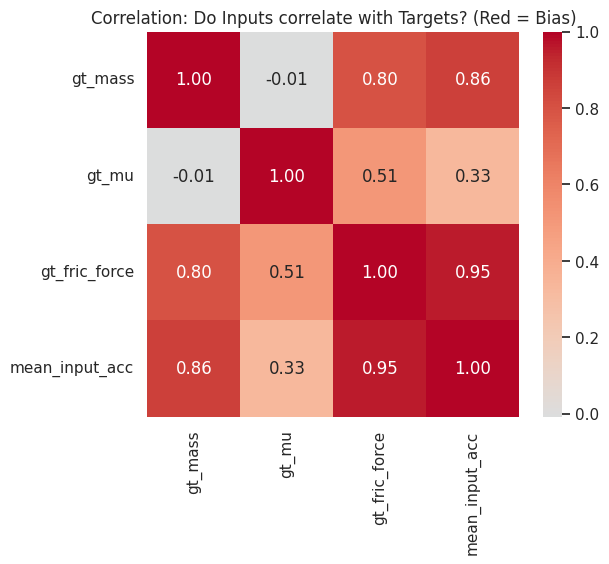

In [9]:
# ==========================================
# 6. CORRELATION MATRIX (Bias Check)
# ==========================================
if 'df' in locals():
    print("\n--- Correlation Analysis (Bias Check) ---")
    # Calculate mean input acceleration for every row to check for bias
    acc_cols = [c for c in df.columns if 'input_acc' in c]
    df['mean_input_acc'] = df[acc_cols].abs().mean(axis=1)
    
    cols_to_corr = ['gt_mass', 'gt_mu', 'gt_fric_force', 'mean_input_acc']
    corr = df[cols_to_corr].corr()
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title("Correlation: Do Inputs correlate with Targets? (Red = Bias)")
    plt.show()

In [10]:
# ==========================================
# 7. UNIQUENESS & DUPLICATES CHECK
# ==========================================
if 'df' in locals():
    target_cols = ['gt_mass', 'gt_mu', 'gt_fric_force']
    
    print("\n--- Checking for Duplicates (Same Values) ---")
    print(f"Total Rows: {len(df)}")
    
    # 1. Check each column individually
    for col in target_cols:
        num_unique = df[col].nunique()
        num_dups = len(df) - num_unique
        print(f"\nColumn '{col}':")
        print(f"  - Unique Values: {num_unique}")
        print(f"  - Duplicates:    {num_dups}")
        if num_dups > 0:
            print(f"  - Most frequent value: {df[col].mode()[0]} (appears {df[col].value_counts().iloc[0]} times)")

    # 2. Check for exact duplicate environments (Mass + Mu + Force matches exactly)
    # This checks if the same "environment" was sampled more than once
    combo_dups = df.duplicated(subset=target_cols).sum()
    print(f"\n------------------------------------------------")
    print(f"Exact Duplicate Environments (All 3 match): {combo_dups}")
    
    if combo_dups > 0:
        print("Note: Some environments have identical parameters.")
        # Optional: Display the duplicates
        # display(df[df.duplicated(subset=target_cols, keep=False)].sort_values(by=target_cols).head(6))
    else:
        print("✅ All environments have unique parameter combinations.")


--- Checking for Duplicates (Same Values) ---
Total Rows: 40960

Column 'gt_mass':
  - Unique Values: 40905
  - Duplicates:    55
  - Most frequent value: 2.9148428440093994 (appears 3 times)

Column 'gt_mu':
  - Unique Values: 40876
  - Duplicates:    84
  - Most frequent value: 0.2059234380722046 (appears 2 times)

Column 'gt_fric_force':
  - Unique Values: 40933
  - Duplicates:    27
  - Most frequent value: 1.6041282415390017 (appears 2 times)

------------------------------------------------
Exact Duplicate Environments (All 3 match): 0
✅ All environments have unique parameter combinations.


Found 2 environments with Force = 12.53954029083252
Indices being plotted: [441, 2276]


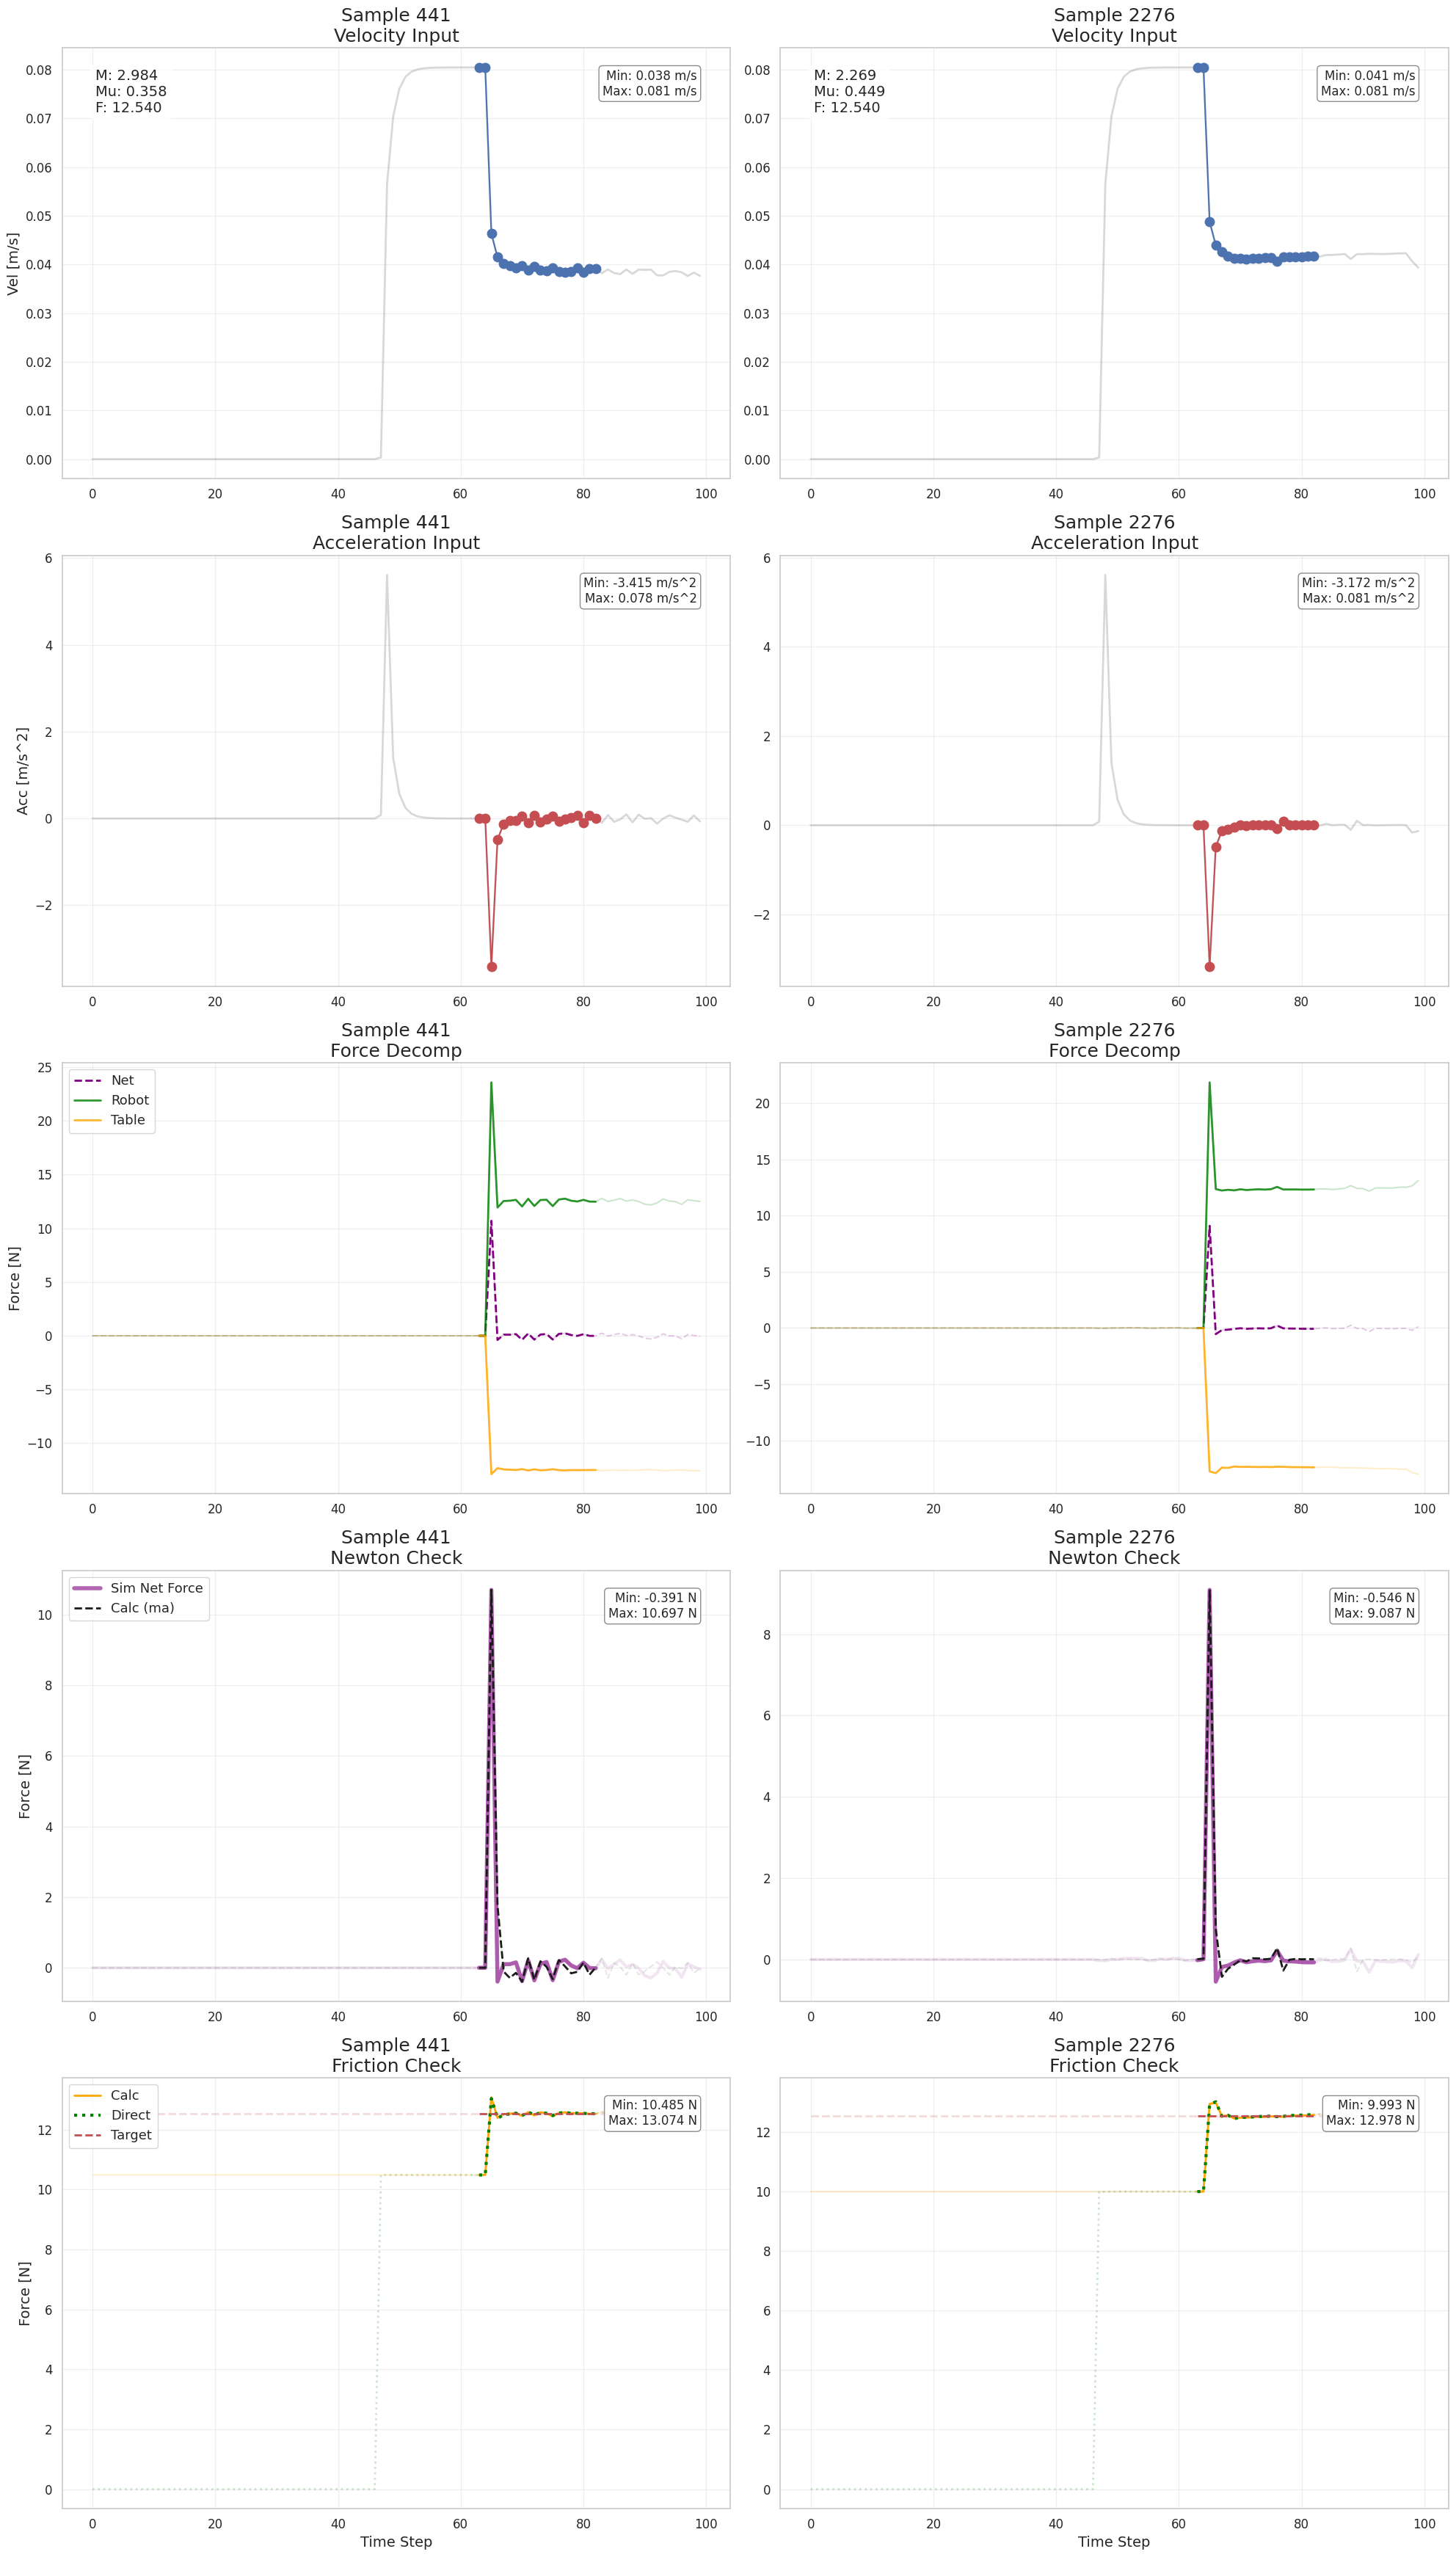

In [11]:
# ==========================================
# 9. INSPECT DUPLICATE FRICTION FORCE ENVIRONMENTS (Grid + Highlight + Min/Max)
# ==========================================
if 'df' in locals():
    # --- CONFIGURATION ---
    AXIS_MOTION = 3   
    AXIS_VERTICAL = 5 
    G = 9.81
    MAX_SAMPLES_TO_PLOT = 4 

    # 1. FIND DUPLICATES
    dups = df[df.duplicated(subset=['gt_fric_force'], keep=False)]
    
    if len(dups) > 0:
        target_force_val = dups.iloc[0]['gt_fric_force']
        target_indices = df[df['gt_fric_force'] == target_force_val].index.tolist()
        
        if len(target_indices) > MAX_SAMPLES_TO_PLOT:
            print(f"Found {len(target_indices)} duplicates. Showing first {MAX_SAMPLES_TO_PLOT}...")
            target_indices = target_indices[:MAX_SAMPLES_TO_PLOT]
        else:
            print(f"Found {len(target_indices)} environments with Force = {target_force_val}")
            
        print(f"Indices being plotted: {target_indices}")
    else:
        print("No duplicates found! Picking 2 random indices to demonstrate grid.")
        target_indices = [np.random.randint(0, len(df)) for _ in range(2)]

    # 2. SETUP PLOT GRID (Massive Size)
    num_cols = len(target_indices)
    num_rows = 5
    # Width: 10 inches per column, Height: 7 inches per row (Total 35)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10 * num_cols, 35), squeeze=False)

    # --- HELPER TO ADD MIN/MAX TEXT ---
    def add_min_max_text(ax, data, unit=""):
        dmin, dmax = np.min(data), np.max(data)
        stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
        # Place at Top-Right
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # 3. LOOP THROUGH INDICES (COLUMNS)
    for col_idx, sample_idx in enumerate(target_indices):
        row = df.iloc[sample_idx]
        
        # --- PARSE METADATA ---
        gt_fric_force_val = row['gt_fric_force']
        if isinstance(gt_fric_force_val, str):
            gt_fric_force_val = float(gt_fric_force_val.strip('[]'))
            
        # --- EXTRACT DATA ---
        raw_acc = get_sequence_data(row, "raw_ee_acc")
        raw_vel = get_sequence_data(row, "raw_ee_vel")
        
        input_cols = [c for c in df.columns if "input_acc_" in c]
        win_len = len(input_cols)
        input_acc = get_flat_window(row, "input_acc", win_len)
        input_vel = get_flat_window(row, "input_vel", win_len)
        
        lhs_wrench = get_sequence_data(row, "pinn_LHS_wrench")
        rhs_acc = get_sequence_data(row, "pinn_RHS_acc")
        robot_wrench = get_sequence_data(row, "pinn_robot_wrench")
        table_wrench = get_sequence_data(row, "pinn_table_wrench")
        
        start_t = int(row['start_t'])
        time_steps = np.arange(start_t, start_t + win_len)

        # --- CALCULATIONS ---
        # Newton Check
        net_force_sim = lhs_wrench[:, AXIS_MOTION]
        acc_sim = rhs_acc[:, AXIS_MOTION]
        net_force_calc = row['gt_mass'] * acc_sim

        # Friction Check
        # Method A (Indirect)
        robot_force_vertical = robot_wrench[:, AXIS_VERTICAL]
        normal_force_calc = (row['gt_mass'] * G) - robot_force_vertical
        fric_force_calc_profile = row['gt_mu'] * normal_force_calc
        
        # Method B (Direct)
        normal_force_direct = table_wrench[:, AXIS_VERTICAL]
        fric_force_direct_profile = row['gt_mu'] * normal_force_direct
        
        fric_force_gt_line = np.full_like(fric_force_calc_profile, gt_fric_force_val)

        # --- PLOTTING ROW BY ROW ---
        FONT_SIZE = 14
        TITLE_SIZE = 18
        LEGEND_SIZE = 13

        # Row 0: Velocity
        ax = axes[0, col_idx]
        ax.plot(raw_vel[:, AXIS_MOTION], color='gray', alpha=0.3, linewidth=2)
        ax.plot(time_steps, input_vel, 'b-o', label='Input', markersize=9)
        
        ax.set_title(f"Sample {sample_idx}\nVelocity Input", fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', which='major', labelsize=12)
        add_min_max_text(ax, input_vel, "m/s") # Add Min/Max
        if col_idx == 0: ax.set_ylabel("Vel [m/s]", fontsize=FONT_SIZE)
        ax.grid(True, alpha=0.3)

        # Row 1: Acceleration
        ax = axes[1, col_idx]
        ax.plot(raw_acc[:, AXIS_MOTION], color='gray', alpha=0.3, linewidth=2)
        ax.plot(time_steps, input_acc, 'r-o', label='Input', markersize=9)
        
        ax.set_title(f"Sample {sample_idx}\nAcceleration Input", fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', which='major', labelsize=12)
        add_min_max_text(ax, input_acc, "m/s^2") # Add Min/Max
        if col_idx == 0: ax.set_ylabel("Acc [m/s^2]", fontsize=FONT_SIZE)
        ax.grid(True, alpha=0.3)

        # Row 2: Force Decomposition
        ax = axes[2, col_idx]
        ax.plot(lhs_wrench[:, AXIS_MOTION], color='purple', linestyle='--', alpha=0.2)
        ax.plot(robot_wrench[:, AXIS_MOTION], color='green', alpha=0.2)
        ax.plot(table_wrench[:, AXIS_MOTION], color='orange', alpha=0.2)
        
        # Highlighted Window
        net_win = lhs_wrench[time_steps, AXIS_MOTION]
        rob_win = robot_wrench[time_steps, AXIS_MOTION]
        tab_win = table_wrench[time_steps, AXIS_MOTION]
        
        ax.plot(time_steps, net_win, label='Net', color='purple', linestyle='--', linewidth=2)
        ax.plot(time_steps, rob_win, label='Robot', color='green', alpha=0.8, linewidth=2)
        ax.plot(time_steps, tab_win, label='Table', color='orange', alpha=0.8, linewidth=2)
        
        ax.set_title(f"Sample {sample_idx}\nForce Decomp", fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', which='major', labelsize=12)
        if col_idx == 0: 
            ax.set_ylabel("Force [N]", fontsize=FONT_SIZE)
            ax.legend(loc='upper left', fontsize=LEGEND_SIZE) # Moved legend to Left to avoid overlap
        ax.grid(True, alpha=0.3)

        # Row 3: Newton Check
        ax = axes[3, col_idx]
        ax.plot(net_force_sim, color='purple', linewidth=3, alpha=0.1)
        ax.plot(net_force_calc, 'k--', linewidth=1.5, alpha=0.1)
        
        # Highlighted
        sim_win = net_force_sim[time_steps]
        calc_win = net_force_calc[time_steps]
        
        ax.plot(time_steps, sim_win, color='purple', linewidth=4, alpha=0.6, label='Sim Net Force')
        ax.plot(time_steps, calc_win, 'k--', label='Calc (ma)', linewidth=2)
        
        ax.set_title(f"Sample {sample_idx}\nNewton Check", fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', which='major', labelsize=12)
        add_min_max_text(ax, sim_win, "N") # Add Min/Max for Sim Force
        if col_idx == 0: 
            ax.set_ylabel("Force [N]", fontsize=FONT_SIZE)
            ax.legend(loc='upper left', fontsize=LEGEND_SIZE)
        ax.grid(True, alpha=0.3)

        # Row 4: Friction Check
        ax = axes[4, col_idx]
        ax.plot(fric_force_calc_profile, color='orange', alpha=0.2)
        ax.plot(fric_force_direct_profile, color='green', linestyle=':', linewidth=2, alpha=0.2)
        ax.plot(fric_force_gt_line, 'r--', linewidth=2, alpha=0.2)
        
        # Highlighted
        fric_calc_win = fric_force_calc_profile[time_steps]
        fric_dir_win = fric_force_direct_profile[time_steps]
        
        ax.plot(time_steps, fric_calc_win, label='Calc', color='orange', linewidth=2)
        ax.plot(time_steps, fric_dir_win, label='Direct', color='green', linestyle=':', linewidth=3)
        ax.plot(time_steps, fric_force_gt_line[time_steps], 'r--', label='Target', linewidth=2)
        
        ax.set_title(f"Sample {sample_idx}\nFriction Check", fontsize=TITLE_SIZE)
        ax.set_xlabel("Time Step", fontsize=FONT_SIZE)
        ax.tick_params(axis='both', which='major', labelsize=12)
        add_min_max_text(ax, fric_calc_win, "N") # Add Min/Max for Calculated Friction
        if col_idx == 0: 
            ax.set_ylabel("Force [N]", fontsize=FONT_SIZE)
            ax.legend(loc='upper left', fontsize=LEGEND_SIZE)
        ax.grid(True, alpha=0.3)
        
        # Add metadata text box (Top Left)
        info_text = f"M: {row['gt_mass']:.3f}\nMu: {row['gt_mu']:.3f}\nF: {gt_fric_force_val:.3f}"
        axes[0, col_idx].text(0.05, 0.95, info_text, transform=axes[0, col_idx].transAxes, 
                              verticalalignment='top', fontsize=14,
                              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()